# Real cycling data walkthrough

This notebook processes genuine battery-cycling data: the small vendored test
fixture `tests/data/cycler_cc_harmonized_raw.parquet` (10 261 rows, 18 cycles
of constant-current cycling, originally recorded at IFE, Norway). It uses the
`CellpyCellCore` class, which orchestrates the engine and adds C-rates and
half-cell cycle modes on top of the plain
[quickstart](quickstart.md) pipeline.

Run it from a checkout of the repository so the fixture path resolves.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

from cellpycore import CellpyCellCore, Data

FIXTURE = Path("../../tests/data/cycler_cc_harmonized_raw.parquet").resolve()
raw = pl.read_parquet(FIXTURE)
print(f"{raw.height} rows, {raw.width} columns")

10261 rows, 29 columns


## 1. A first look at the raw data

The frame is already in the
[harmonized raw schema](../specifications/harmonized-raw.md): `potential` in
volts, `current` in amperes, times in seconds, capacities cumulative per
cycle and direction.

In [2]:
raw.select(
    "datapoint_num",
    "test_time",
    "cycle_num",
    "step_num",
    "current",
    "potential",
    "cumulative_charge_capacity",
).head()

datapoint_num,test_time,cycle_num,step_num,current,potential,cumulative_charge_capacity
i64,f64,i64,i64,f64,f64,f64
1,300.010482,1,1,0.0,3.097617,0.0
2,600.014947,1,1,0.0,3.10008,0.0
3,900.026371,1,1,0.0,3.101312,0.0
4,1200.039773,1,1,0.0,3.102852,0.0
5,1500.051275,1,1,0.0,3.10316,0.0


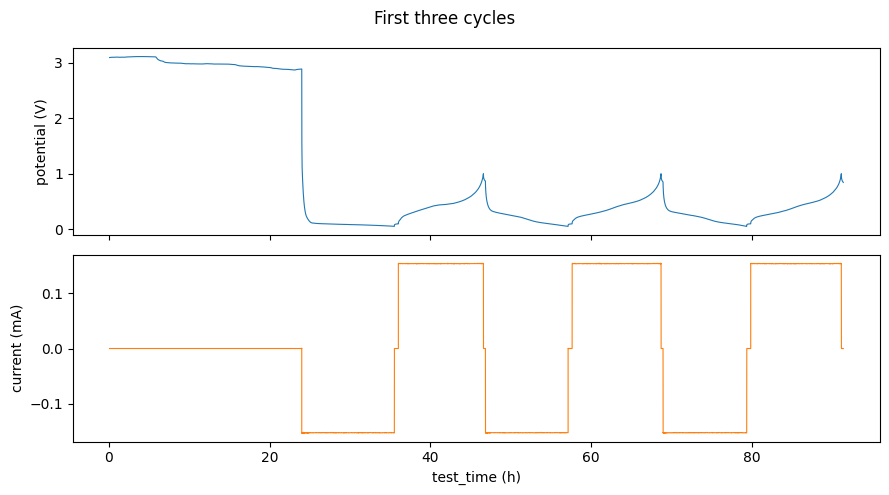

In [3]:
first_cycles = raw.filter(pl.col("cycle_num") <= 3)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
ax1.plot(first_cycles["test_time"] / 3600, first_cycles["potential"], lw=0.8)
ax1.set_ylabel("potential (V)")
ax2.plot(
    first_cycles["test_time"] / 3600,
    first_cycles["current"] * 1000,
    lw=0.8,
    color="tab:orange",
)
ax2.set_ylabel("current (mA)")
ax2.set_xlabel("test_time (h)")
fig.suptitle("First three cycles")
fig.tight_layout()

## 2. Process with `CellpyCellCore`

The class handles the `cycle_mode` string for you. This cell is an **anode
half-cell**, so coulombic efficiency is computed in the inverted direction
(`CE = 100 * charge / discharge`). `make_core_step_table` also estimates a
per-step C-rate from `nom_cap_abs` (absolute, in the same unit as
capacity — pass your cell's real value).

In [4]:
NOM_CAP = 0.001  # Ah — nominal capacity of this small test cell

core = CellpyCellCore()
core.data = Data.from_raw_frame(raw)
core.cycle_mode = "anode"

data = core.make_core_step_table(core.data, nom_cap_abs=NOM_CAP)
data = core.make_core_summary(data, current_conversion_factor=1.0)

print(f"steps:   {data.steps.height} rows")
print(f"summary: {data.summary.height} cycles")

steps:   103 rows
summary: 18 cycles


## 3. The step table

One row per sequential step with per-step statistics, the classified
`step_type`, and the estimated C-rate.

In [5]:
data.steps.select(
    "cycle_num",
    "step_num",
    "step_type",
    "c_rate",
    "current_mean",
    "potential_first",
    "potential_last",
).head(8)

cycle_num,step_num,step_type,c_rate,current_mean,potential_first,potential_last
i64,i64,str,f64,f64,f64,f64
1,1,"""ocvrlx_down""",0.0,0.0,3.097617,2.88916
1,2,"""ir""",0.00066,6.6289e-7,2.8907,2.8907
1,3,"""discharge""",0.15221,-0.000152,2.839894,0.049894
1,4,"""ir""",0.00004,-4.3646e-8,0.064366,0.064366
1,5,"""ocvrlx_up""",0.0,0.0,0.0696,0.095465
1,6,"""charge""",0.15362,0.000154,0.110245,1.000113
1,7,"""ir""",0.00031,3.0962e-7,0.995803,0.995803
1,8,"""ocvrlx_down""",0.0,0.0,0.990568,0.866787


In [6]:
data.steps.group_by("step_type").len().sort("len", descending=True)

step_type,len
str,u32
"""ir""",33
"""discharge""",18
"""ocvrlx_down""",18
"""ocvrlx_up""",17
"""charge""",17


## 4. Capacity fade and coulombic efficiency

The per-cycle summary is where degradation trends live.

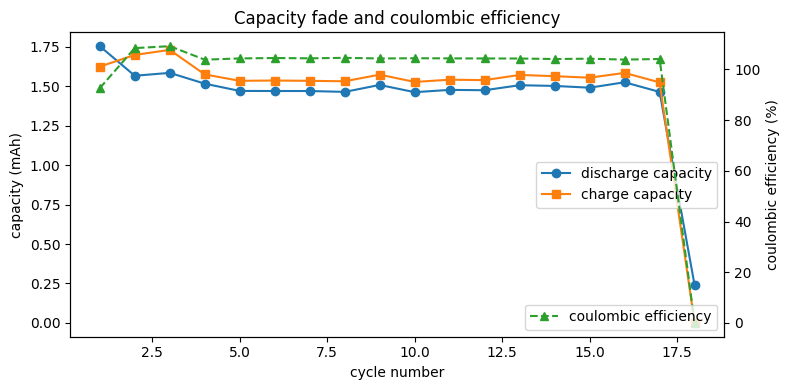

In [7]:
summary = data.summary
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(
    summary["cycle_num"],
    summary["discharge_capacity"] * 1000,
    "o-",
    label="discharge capacity",
)
ax1.plot(
    summary["cycle_num"],
    summary["charge_capacity"] * 1000,
    "s-",
    label="charge capacity",
)
ax1.set_xlabel("cycle number")
ax1.set_ylabel("capacity (mAh)")
ax1.legend(loc="center right")

ax2 = ax1.twinx()
ax2.plot(
    summary["cycle_num"],
    summary["coulombic_efficiency"],
    "^--",
    color="tab:green",
    label="coulombic efficiency",
)
ax2.set_ylabel("coulombic efficiency (%)")
ax2.legend(loc="lower right")
ax1.set_title("Capacity fade and coulombic efficiency")
fig.tight_layout()

In [8]:
summary.select(
    "cycle_num",
    "charge_capacity",
    "discharge_capacity",
    "coulombic_efficiency",
    "charge_c_rate",
    "discharge_c_rate",
).head(6)

cycle_num,charge_capacity,discharge_capacity,coulombic_efficiency,charge_c_rate,discharge_c_rate
i64,f64,f64,f64,f64,f64
1,0.001625,0.001755,92.610791,0.15362,0.15221
2,0.0017,0.001567,108.426838,0.15361,0.15232
3,0.001732,0.001586,109.19373,0.15359,0.15232
4,0.001576,0.001517,103.86601,0.30553,0.30444
5,0.001535,0.001471,104.358191,0.30549,0.30439
6,0.001537,0.001471,104.517674,0.30547,0.30444


## Next steps

- `core.add_scaled_summary_columns(...)` adds gravimetric / areal / absolute
  variants of the capacity-like columns and a normalized (equivalent) cycle
  index — see the
  [standalone-use guide](../user-guide/standalone-use.md#useful-knobs).
- `make_core_summary(..., exclude_step_types=["cv_"])` builds a summary with
  the capacity contribution of matching step types subtracted.
- The exact meaning of every output column is specified in the
  [step table](../specifications/step-table.md) and
  [cycle table](../specifications/cycle-table.md) documents.